<span style="font-size:25px; font-weight:bold">Name: Wondwosen Muhea</span><br>
<span style="font-size:20px; font-weight:bold">Course: Advanced Big Data and Data Mining (MSCS-634-M40) </span><br>
<span style="font-size:16px; font-weight:bold">Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering</span><br>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix, homogeneity_score, completeness_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from scipy.stats import mode
import matplotlib.pyplot as plt
from itertools import product
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score


In [2]:
# Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
# Convert to DataFrame for easier inspection
df = pd.DataFrame(X, columns=feature_names)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Optionally convert scaled data to DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
df_scaled.head()
print("Data description")
df_scaled.describe()

Data description


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,7.943708e-15,3.592632e-16,-4.066660e-15,-7.983626e-17,-7.983626e-17,-3.991813e-17,9.979533e-16,-5.588538e-16,-1.656602e-15,-3.442939e-16,1.636643e-15,2.235415e-15,-1.197544e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246e+00,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-8.854682e-01,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,9.595986e-02,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,8.089974e-01,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515e+00,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00


#### Analysis of Scaling
Why We Scale Data Before Hierarchical Clustering
- Hierarchical clustering and most distance-based algorithms in gerneal relies on computing distances between data points.
- Agglomerative clustering often uses Euclidean distance
- Features with larger numeric ranges dominate the distance calculation if not scaled
Scaling Solves
- All features contribute equally to distance
- Clustering reflects true structure, not value magnitude

In [3]:
# Evaluate Hierarchical clustering with different number of clusters
cluster_range = range(2, 6)
silhouette_scores = []
ari_scores = []

for n_clusters in cluster_range:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    
    if n_clusters == 3:
        ari = adjusted_rand_score(y, labels)
        best_labels = labels  # Save for confusion matrix and PCA plot
    else:
        ari = np.nan
    ari_scores.append(ari)

# Create summary DataFrame
evaluation_df = pd.DataFrame({
    'n_clusters': list(cluster_range),
    'silhouette_score': silhouette_scores,
    'adjusted_rand_index': ari_scores
})

# Display table
print("Agglomerative Clustering Evaluation")
display(evaluation_df)

Agglomerative Clustering Evaluation


,n_clusters,silhouette_score,adjusted_rand_index
0,2,0.267013,NaN
1,3,0.277444,0.789933
2,4,0.225837,NaN
3,5,0.186742,NaN


#### Analysis
Silhouette Score
- have values (-1 to 1) indicates how well each point fits within its cluster.
- value Close to 1 = well-clustered and 0 = overlapping clusters with Negative value = wrong clustering
- In the above results: Best silhouette score is at 3 clusters (0.2774)
- Score drops as clusters increase beyond 3 (over-segmentation)

Adjusted Rand Index (ARI)

- Measures clustering accuracy vs ground truth labels with values between -1 to 1
- 1 = perfect match with true labels and 0 = random clustering
- Only be computed when the number of predicted clusters matches the ground truth labels.
- Only available at n_clusters = 3, because the wine dataset has 3 true classes,
- ARI = 0.7899 for k=3, meaning the clustering matches the real wine classes quite well.

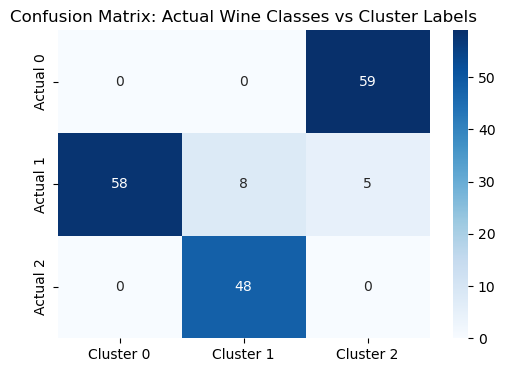

In [4]:
# Confusion matrix (only for n_clusters = 3)
conf_matrix = confusion_matrix(y, best_labels)
conf_df = pd.DataFrame(conf_matrix,
                       index=[f"Actual {i}" for i in np.unique(y)],
                       columns=[f"Cluster {i}" for i in np.unique(best_labels)])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Actual Wine Classes vs Cluster Labels")
plt.show()

In [5]:
def remap_clusters(cluster_labels, true_labels):
    """
    Reassigns cluster labels to match the majority true label in each cluster.
    
    Parameters:
    - cluster_labels: array-like, predicted cluster labels from an unsupervised algorithm
    - true_labels: array-like, actual class labels (used only for evaluation)
    
    Returns:
    - remapped_labels: array of cluster labels aligned with true labels
    - mapping: dict showing how original cluster labels were mapped
    """
    label_map = {}
    for cluster in np.unique(cluster_labels):
        mask = cluster_labels == cluster
        majority_label = mode(true_labels[mask], keepdims=False).mode
        label_map[cluster] = majority_label
    
    remapped_labels = np.vectorize(label_map.get)(cluster_labels)
    return remapped_labels, label_map

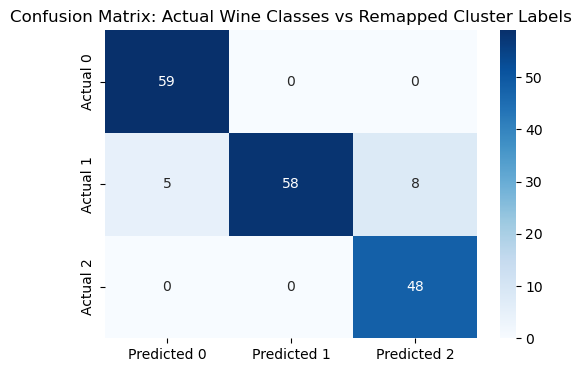

In [6]:
# Confusion matrix (only for n_clusters = 3) after cluster remapping
remapped_labels, label_map = remap_clusters(best_labels, y)
conf_matrix = confusion_matrix(y, remapped_labels)
conf_df = pd.DataFrame(conf_matrix,
                       index=[f"Actual {i}" for i in np.unique(y)],
                       columns=[f"Predicted {i}" for i in np.unique(remapped_labels)])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Actual Wine Classes vs Remapped Cluster Labels")
plt.show()

#### Analaysis
- The confusion matrix heatmap compares True labels and Predicted cluster labels
- But the cluster labels (e.g., 0, 1, 2) are arbitrary — they don't match true classes by default.
- So remapping cluster names to the true labes is required to better interpret the heatmaps
- We can clearly see diagonal dominance in the second heatmap. Each predicted cluster now matches a real class
- The first heatmap, no diagonal dominance is observed which can be misinterpreted as bad performanace

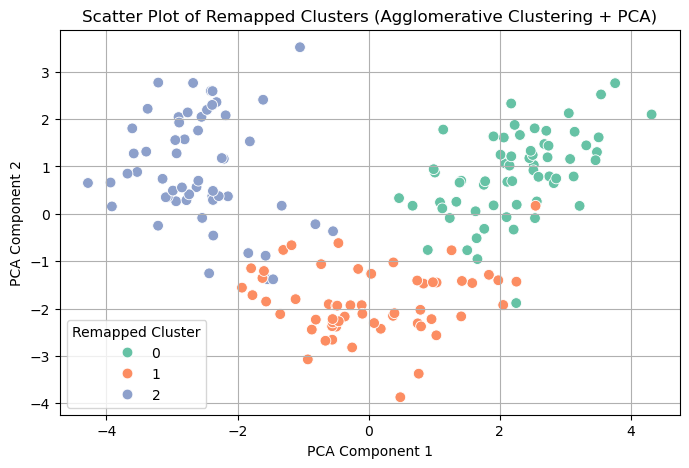

In [7]:
# Scattering Plot
# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=remapped_labels, palette='Set2', s=60)
plt.title("Scatter Plot of Remapped Clusters (Agglomerative Clustering + PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Remapped Cluster")
plt.grid(True)
plt.show()

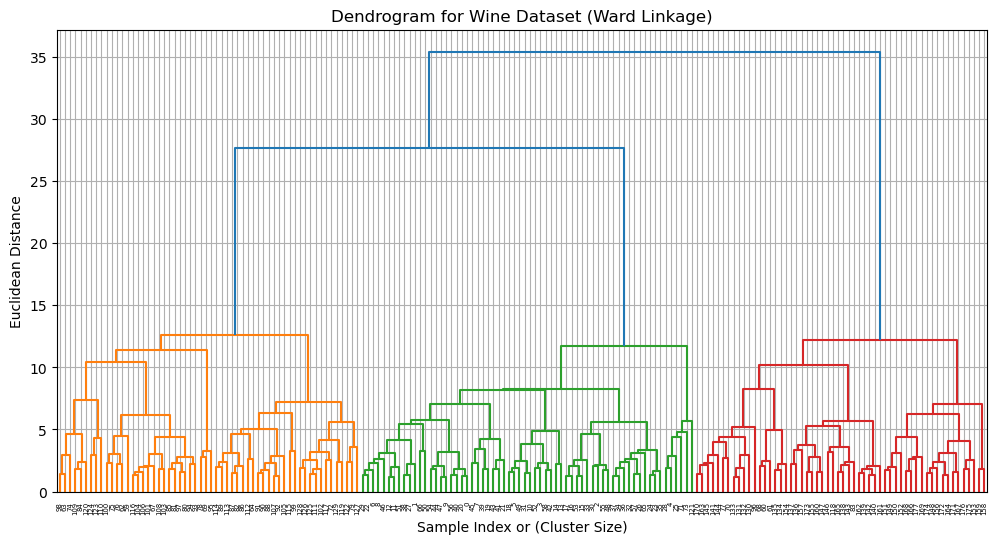

In [8]:
# Use Ward's method for linkage (minimizes variance within clusters)
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           truncate_mode='level',  # Show only top levels
           p=30)  # Adjust this value to zoom into more or fewer merges

plt.title("Dendrogram for Wine Dataset (Ward Linkage)")
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Euclidean Distance")
plt.grid(True)
plt.show()

#### Key Observations from Dendrogram
#### Clear 3-cluster structure
- There are three large branches in the dendrogram, separated at a Euclidean distance around 25–30, suggesting a natural division into 3 distinct clusters.
- This structure aligns well with the known three wine classes (Class 0, 1, 2).
#### Cluster compactness
- Each major branch shows tight sub-cluster groupings near the base (distance 0–10), meaning that intra-cluster similarity is high.
- Ward linkage tends to build balanced clusters, which is visually evident in the relative symmetry of the three main branches.
#### Cutting the tree
- A horizontal cut at ~28 cleanly separates the dataset into three major clusters.
- Cutting slightly lower (e.g., at distance ~20) would lead to 4 or more clusters, fragmenting the structure.
#### Interpretability
- Dendrograms provide transparent insight into the hierarchy of clusters — useful for justifying k = 3.
- The merge heights indicate the relative dissimilarity between clusters — higher merges reflect more dissimilar groups being merged.

### 3. DBSCAN Clustering

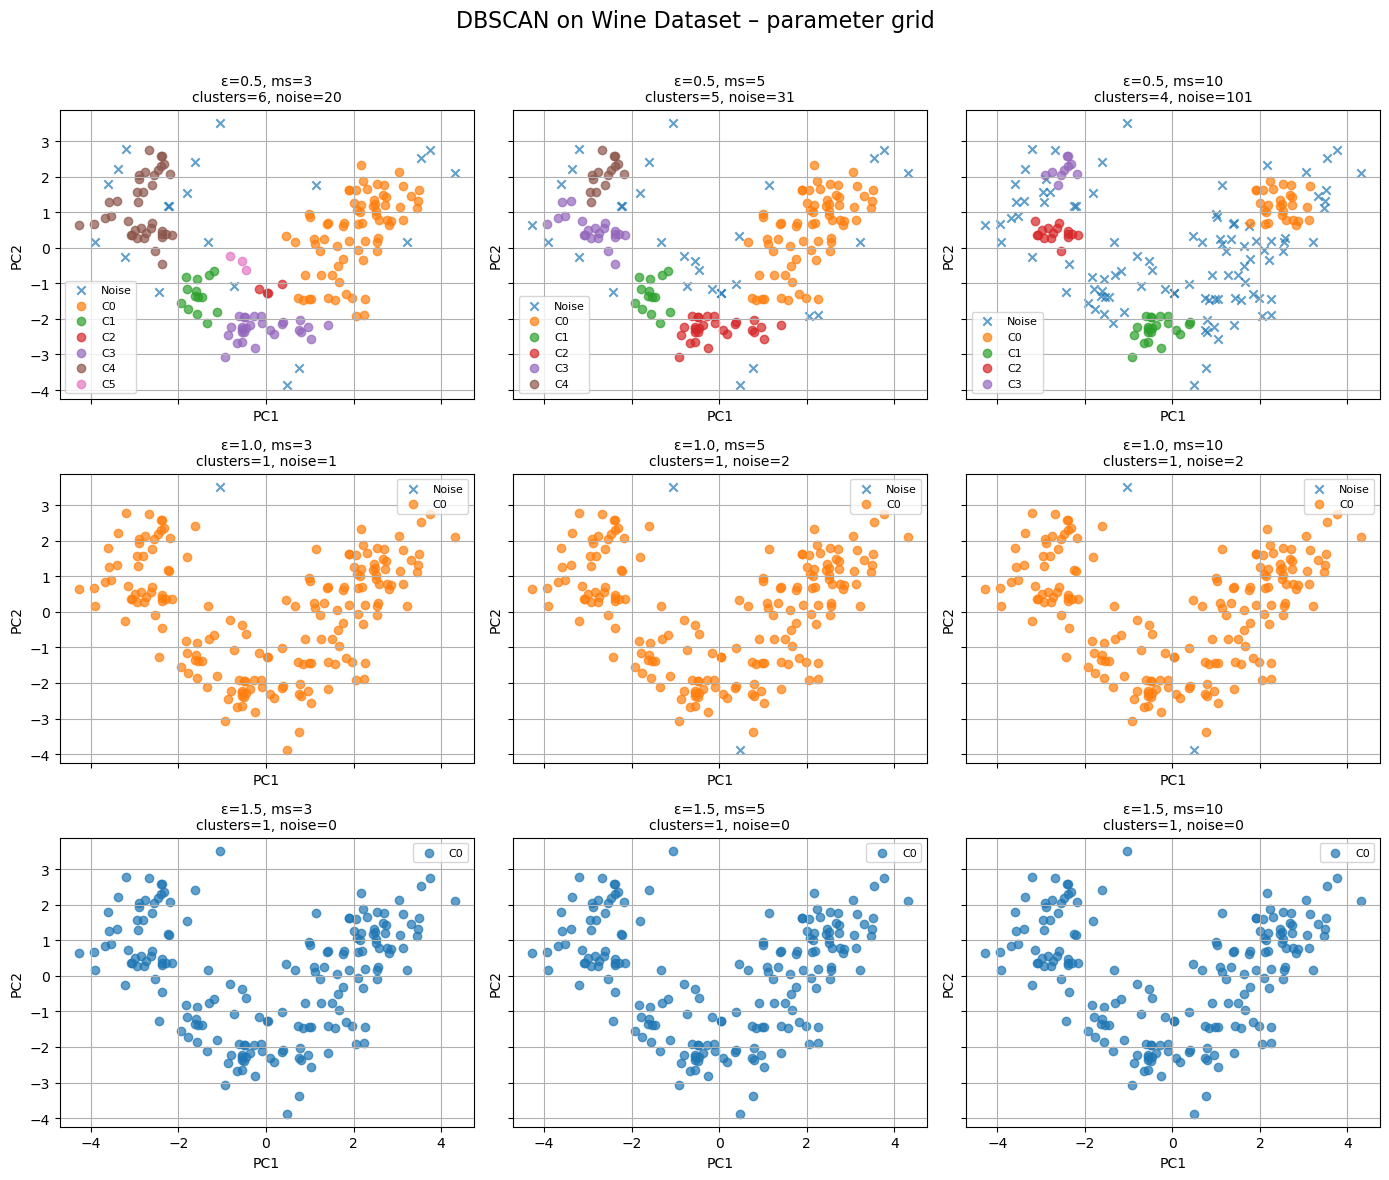


DBSCAN Evaluation Metrics


,eps,min_samples,n_clusters,n_noise,silhouette_score,homogeneity_score,completeness_score
0,0.5,3,6,20,0.273198,0.670743,0.459031
1,0.5,5,5,31,0.323036,0.625026,0.416493
2,0.5,10,4,101,0.044663,0.431508,0.373751
3,1.0,3,1,1,NaN,NaN,NaN
4,1.0,5,1,2,NaN,NaN,NaN
5,1.0,10,1,2,NaN,NaN,NaN
6,1.5,3,1,0,NaN,NaN,NaN
7,1.5,5,1,0,NaN,NaN,NaN
8,1.5,10,1,0,NaN,NaN,NaN


In [9]:

# 1. Load & preprocess
# ----------------------------
wine       = load_wine()
X_scaled   = StandardScaler().fit_transform(wine.data)
true_label = wine.target

pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_scaled)

# ----------------------------
# 2. Parameter grid
# ----------------------------
eps_values         = [0.5, 1.0, 1.5]
min_samples_values = [3, 5, 10]

results = []

# ----------------------------
# 3. Plot grid setup
# ----------------------------
fig, axes = plt.subplots(
    nrows=len(eps_values), ncols=len(min_samples_values),
    figsize=(14, 12), sharex=True, sharey=True
)
axes = axes.ravel()   # flatten for easier indexing

# ----------------------------
# 4. Grid search + sub-plots
# ----------------------------
for idx, (eps, ms) in enumerate(product(eps_values, min_samples_values)):
    db = DBSCAN(eps=eps, min_samples=ms)
    labels = db.fit_predict(X_pca)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = np.count_nonzero(labels == -1)

    if n_clusters > 1:
        sil  = silhouette_score(X_pca, labels)
        homo = homogeneity_score(true_label, labels)
        comp = completeness_score(true_label, labels)
    else:
        sil = homo = comp = np.nan

    results.append(
        dict(eps=eps, min_samples=ms, n_clusters=n_clusters,
             n_noise=n_noise, silhouette_score=sil,
             homogeneity_score=homo, completeness_score=comp)
    )

    # --- plotting ---
    ax = axes[idx]
    for lbl in np.unique(labels):
        mask = labels == lbl
        marker = 'x' if lbl == -1 else 'o'
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            marker=marker, alpha=0.7,
            label='Noise' if lbl == -1 else f'C{lbl}'
        )
    ax.set_title(
        f"ε={eps}, ms={ms}\nclusters={n_clusters}, noise={n_noise}",
        fontsize=10
    )
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True)

plt.suptitle("DBSCAN on Wine Dataset – parameter grid", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ----------------------------
# 5. Display metrics table
# ----------------------------
results_df = pd.DataFrame(results)
print("\nDBSCAN Evaluation Metrics")
display(results_df)


### Analysis
##### Density sensitivity (ε)
- ε = 0.5 → meaningful clustering.
- With min_samples = 3–10 we see 4–6 compact groups plus some noise.
- ε = 1.0 → almost the entire data cloud fuses into one mega-cluster (only a couple of points marked noise).
- ε = 1.5 → identical to ε = 1.0; DBSCAN cannot distinguish sub-groups at this radius.
##### Noise distribution
- At ε = 0.5, increasing min_samples inflates the noise set because fewer points satisfy the larger core requirement.
- At ε ≥ 1.0, virtually no noise (radius so wide every point finds neighbors).
##### Metric trade-offs
#### Silhouette vs. Homogeneity:
- min_samples = 5 delivers the highest silhouette (better intra-cluster density / inter-cluster separation), whereas min_samples = 3 gives marginally better homogeneity/completeness (clusters align more with true wine varietals).
- Both metrics collapse to NaN when DBSCAN yields a single cluster (ε ≥ 1.0).
Overall 
- The wine chemistry data are only density-separable around ε ≈ 0.45–0.60.
- A core size of 4–6 appears optimal; stricter thresholds discard too many points as noise, looser thresholds fragment clusters.

#### Summary
#### Summary of DBSCAN results
- Parameter window used: ε = 0.5, 1.0, 1.5 × min_samples = 3, 5, 10.
- Best density setting (ε = 0.5, min_samples = 5) delivered 5 clusters + 31 noise points with a silhouette ≈ 0.32.
- Quality metrics show partial agreement with the three known varietals (homogeneity ≈ 0.63, completeness ≈ 0.42).
#### Why DBSCAN results in more than 3 clusters
  | Reason                                 | Impact on DBSCAN                                                                                                         |
| -------------------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| **Local-density criterion** (ε radius) | Small ε isolates tight pockets; a single varietal may fracture into several micro-clusters.                              |
| **Sample-count imbalance**             | Denser varietal (class 1) is prone to being partitioned; sparser classes partly flagged as noise.                        |
| **Intrinsic sub-structure**            | Chemical features show multi-modal distributions within each varietal, so DBSCAN treats each mode as a distinct cluster. |
| **Noise labelling**                    | Edge samples removed from cores exaggerate the split count.    |


#### Final Conclusion
#### Interpretation & recommendation

If goal = replicate known three varietals
- Hierarchical (or K-Means/GMM with k = 3) is simpler, more interpretable, and better aligned with labels (higher homogeneity & completeness).
If goal = explore hidden sub-structure
- DBSCAN is valuable: it surfaces density micro-clusters and isolates outliers. Post-processing (merging adjacent cores) can still recover a 3-group view while retaining anomaly information.
### Practical workflow
- Run DBSCAN to detect anomalies and micro-clusters.
- Merge density clusters based on centroid distance to obtain exactly three macro-groups.
- Validate with hierarchical clustering for sanity and interpret chemical feature differences across both levels of granularity.

In short, DBSCAN over-segmentation is not an error but a reflection of genuine local density variations; hierarchical clustering enforces the expected 3-cluster structure and scores better against the ground truth. Choosing between them depends on whether the analysis prioritizes exploration or label fidelity.
